# 6장 이진 분류

In [1]:
# 라이브러리 임포트

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔 고딕 폰트의 경로 명시
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

In [2]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot

In [3]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## 6.5 시그모이드 함수

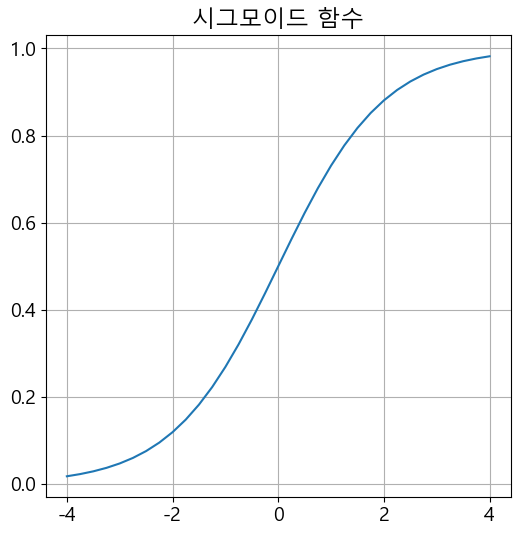

In [4]:
# 넘파이 배열로 x_np를 정의
x_np = np.arange(-4, 4.1, 0.25)

# x_np를 텐서로 변환
x = torch.tensor(x_np).float()

# y값 계산
y = torch.sigmoid(x)

# 그래프 출력
plt.title('시그모이드 함수')
plt.plot(x.data, y.data)
plt.show()


## 6.7 데이터 준비

In [5]:
# 사이킷런 설치
# pip install scikit-learn

In [6]:
# 학습용 데이터 준비

# 라이브러리 임포트
from sklearn.datasets import load_iris

# 데이터 불러오기
iris = load_iris()

# 입력 데이터와 정답 데이터
x_org, y_org = iris.data, iris.target

# 결과 확인
print('원본 데이터', x_org.shape, y_org.shape)

원본 데이터 (150, 4) (150,)


In [7]:
# 데이터 추출
# 클래스는 0 또는 1
# 항목은 sepal_length와 sepal_width

# 3,4 번째 열 추출
x_data = iris.data[:100,2:4]
y_data = iris.target[:100]

# 결과 확인
print('대상 데이터', x_data.shape, y_data.shape)

대상 데이터 (100, 2) (100,)


### 훈련 데이터와 검증 데이터 분할

In [8]:
# 원본 데이터의 사이즈
print(x_data.shape, y_data.shape)

# 훈련 데이터와 검증 데이터로 분할(동시에 셔플)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, train_size=70, test_size=30, random_state=123)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


(100, 2) (100,)
(70, 2) (30, 2) (70,) (30,)


### 훈련 데이터의 산포도 출력

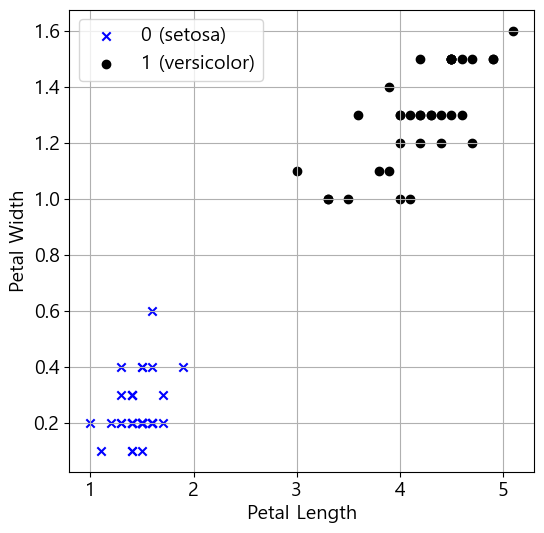

In [9]:
# 산포도 출력

x_t0 = x_train[y_train == 0]
x_t1 = x_train[y_train == 1]

# 정답이 0인 데이터만 추출
plt.scatter(x_t0[:, 0], x_t0[:, 1], marker='x', c='b', label='0 (setosa)')

# 정답이 1인 데이터만 추출
plt.scatter(x_t1[:, 0], x_t1[:, 1], marker='o', c='k', label='1 (versicolor)')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()

x_t0[:,0], x_t0[:,1] 과 x_t1[:,0], x_t1[:,1] 비교

정리하면:

x_t0[:,0] = 클래스 0 꽃들의 첫 번째 feature
x_t0[:,1] = 클래스 0 꽃들의 두 번째 feature
x_t1[:,0] = 클래스 1 꽃들의 첫 번째 feature
x_t1[:,1] = 클래스 1 꽃들의 두 번째 feature

즉,

[:,0] 과 [:,1] 차이

같은 그룹 안에서 열이 다름

첫 번째 feature
두 번째 feature
x_t0 와 x_t1 차이

꽃 종류가 다름

setosa
versicolor

## 6.8 모델 정의

In [10]:
# 입력 차원수 (지금의 경우는 2)
n_input = x_train.shape[1]

# 출력 차원수 
n_output = 1

# 결과 확인
print(f'n_input: {n_input}, n_output: {n_output}')

n_input: 2, n_output: 1


In [11]:
# 모델 정의 
# 2입력 1출력 로지스틱 회귀 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)
        self.sigmoid = nn.Sigmoid()
        
        # 초기값을 전부 1로 함(책이랑 같게 하기 위함)
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)
    
    # 예측 함수 정의
    def forward(self, x):
        # 선형 함수에 입력값을 넣고 계산한 결과
        x1 = self.l1(x)
        
        # 계산 결과에 시그모이드 함수를 적용
        x2 = self.sigmoid(x1)
        
        return x2

In [12]:
# 인스턴스 생성
net = Net(n_input, n_output)

# Net으로 실제 모델 만드는 것
# 1. class Net → 모델 구조 정의
#2. super() → 기본 기능 활성화
#3. net = Net(...) → 실제 모델 생성


## 모델 확인

In [13]:
# 모델 안의 파라미터 확인
# l1.weight와 l1.bias가 존재함을 알 수 있음

for parameter in net.parameters():
    print(parameter)

Parameter containing:
tensor([[1., 1.]], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)


In [14]:
# 모델의 개요 표시 1
print(net)

Net(
  (l1): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [15]:
# 모델의 개요 표시 2
summary(net, (2,))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       3
├─Sigmoid: 1-2                           [1]                       --
Total params: 3
Trainable params: 3
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## 최적화 알고리즘과 손실 함수의 정의

In [16]:
# 손실 함수 : 교차 엔트로피 함수
criterion = nn.BCELoss()

# 학습률
lr = 0.01

# 최적화 함수 : 경사 하가법
optimizer = optim.SGD(net.parameters(), lr=lr)

## 6.9 경사 하강법

In [19]:
# 넘파이 배열 → 파이토치 텐서로 변환
inputs = torch.tensor(x_train).float()
labels1 = torch.tensor(y_train).float().unsqueeze(1)

inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).float().unsqueeze(1)


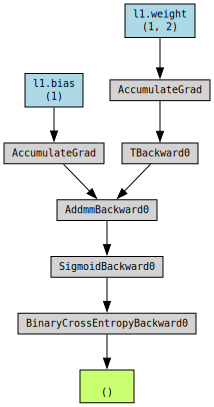

In [20]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels1)

# 손실을 계산 그래프로 출력
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

### 반복 계산

In [21]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수 : 교차 엔트로피 함수
criterion = nn.BCELoss()

# 최적화 함수 : 경사 하가법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수 
num_epochs = 2000

# 기록용 리스트 초기화
history = np.zeros((0,5))

In [22]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):
    # 훈련 페이즈
    
    # 경삿값 초기화
    optimizer.zero_grad()
    
    # 예측 계산
    outputs = net(inputs)
    
    # 손실 계산
    loss = criterion(outputs, labels1)
    
    # 경사 계산
    loss.backward()
    
    # 파라미터 수정
    optimizer.step()
    
    # 손실 저장 (스칼라 값 취득)
    train_loss = loss.item()
    
    # 예측 라벨 (1 또는 0) 계산
    predicted = torch.where(outputs > 0.5, 1, 0)
    
    # 정확도 계산
    train_acc = (predicted == labels1).sum() / len(y_train)
    
    # 예측 페이즈
    
    # 예측 계산
    outputs_test = net(inputs_test)
    
    # 손실 계산
    val_loss = criterion(outputs_test, labels_test)
    
    # 손실 저장 (스칼라 값 취득)
    val_loss = val_loss.item()
    
    # 예측 라벨 (1 또는 0) 계산
    predicted_test = torch.where(outputs_test > 0.5, 1, 0)
    
    # 정확도 계산
    val_acc = (predicted_test == labels_test).sum() / len(y_test)
    
    if (epoch % 10 == 0):
        print (f'Epoch [{epoch}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))

Epoch [0/2000], loss: 1.38417 acc: 0.50000 val_loss: 1.38952, val_acc: 0.50000
Epoch [10/2000], loss: 1.31570 acc: 0.50000 val_loss: 1.32045, val_acc: 0.50000
Epoch [20/2000], loss: 1.24892 acc: 0.50000 val_loss: 1.25309, val_acc: 0.50000
Epoch [30/2000], loss: 1.18406 acc: 0.50000 val_loss: 1.18766, val_acc: 0.50000
Epoch [40/2000], loss: 1.12141 acc: 0.50000 val_loss: 1.12443, val_acc: 0.50000
Epoch [50/2000], loss: 1.06123 acc: 0.50000 val_loss: 1.06369, val_acc: 0.50000
Epoch [60/2000], loss: 1.00384 acc: 0.50000 val_loss: 1.00574, val_acc: 0.50000
Epoch [70/2000], loss: 0.94957 acc: 0.50000 val_loss: 0.95092, val_acc: 0.50000
Epoch [80/2000], loss: 0.89876 acc: 0.50000 val_loss: 0.89956, val_acc: 0.50000
Epoch [90/2000], loss: 0.85174 acc: 0.50000 val_loss: 0.85200, val_acc: 0.50000
Epoch [100/2000], loss: 0.80879 acc: 0.50000 val_loss: 0.80852, val_acc: 0.50000
Epoch [110/2000], loss: 0.77015 acc: 0.50000 val_loss: 0.76937, val_acc: 0.50000
Epoch [120/2000], loss: 0.73596 acc: 0.

## 6.10 결과 확인

In [23]:
# 손실과 정확도 확인

print(f'초기 상태  손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}' )
print(f'최종 상태  손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

초기 상태  손실 : 1.38952  정확도 : 0.50000
최종 상태  손실 : 0.22197  정확도 : 1.00000


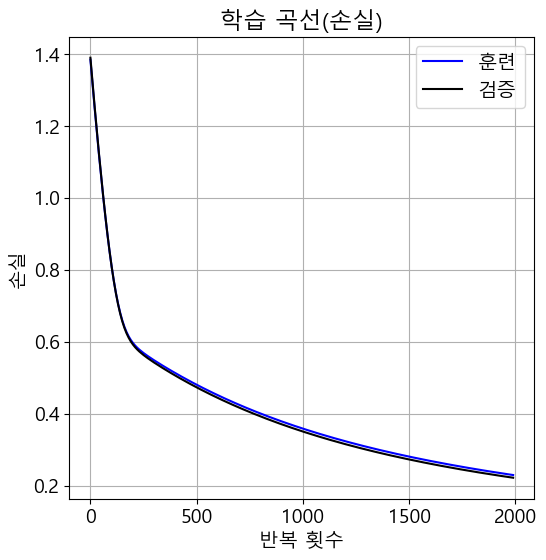

In [24]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b', label='훈련')
plt.plot(history[:,0], history[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

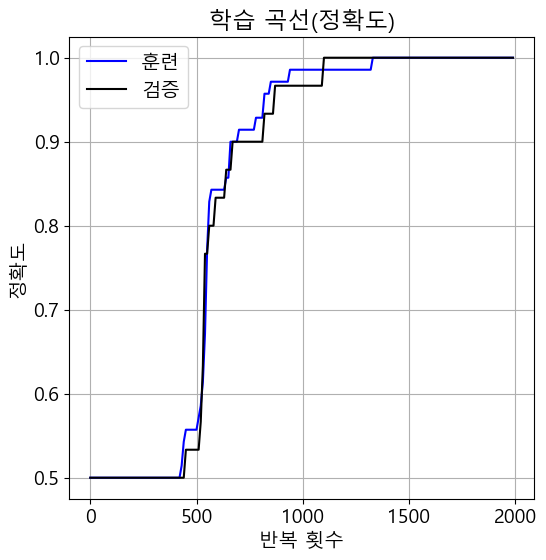

In [25]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], 'b', label='훈련')
plt.plot(history[:,0], history[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

## 결정 겅계 그래프 출력

In [26]:
# 검증 데이터 준비

x_t0 = x_test[y_test==0]
x_t1 = x_test[y_test==1]

In [27]:
# 파라미터 취득

bias = net.l1.bias.data.numpy()
weight = net.l1.weight.data.numpy()
print(f'BIAS = {bias}, WEIGHT = {weight}')

# 결정 경계를 그리기 위해 x1로부터 x2를 계산
def decision(x):
    return(-(bias + weight[0,0] * x)/ weight[0,1])

# 산포도의 x1의 최솟값과 최댓값
xl = np.array([x_test[:,0].min(), x_test[:,0].max()])
yl = decision(xl)

# 결과 확인
print(f'xl = {xl}  yl = {yl}')

BIAS = [-2.0315], WEIGHT = [[0.4621 1.7226]]
xl = [1.2 5. ]  yl = [ 0.8574 -0.162 ]


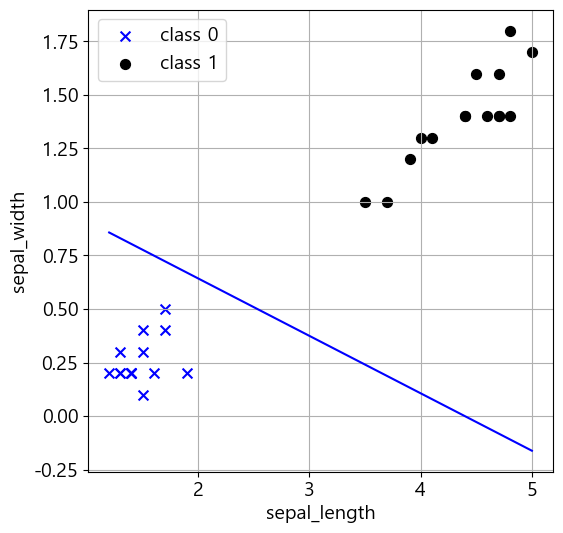

In [28]:
# 산포도 출력
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', 
        c='b', s=50, label='class 0')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', 
        c='k', s=50, label='class 1')

# 결정 경계 직선
plt.plot(xl, yl, c='b')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.show()

## 칼럼 BCELoss 함수와 BCEWithLogistisLoss 함수의 차이

In [29]:
# 모델 정의
# 2입력 1출력 로지스틱 회귀 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)
                
        # 초깃값을 모두 1로 함
        # "딥러닝을 위한 수학"과 조건을 맞추기 위한 목적        
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)        
        
    # 예측 함수 정의
    def forward(self, x):
        # 입력 값과 행렬 곱을 계산
        x1 = self.l1(x)
        return x1

In [30]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수 ： logits가 붙은 교차 엔트로피 함수
criterion = nn.BCEWithLogitsLoss()

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 2000

# 기록용 리스트 초기화
history = np.zeros((0,5))

In [31]:
# 반복 계산 메인 루프

# 반복 루프 시작 전에 반드시 초기화!
history = np.zeros((0, 5))

for epoch in range(num_epochs):
    # 훈련 페이즈
    
    # 경삿값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels1)

    # 경사 계산
    loss.backward()
    
    # 파라미터 수정
    optimizer.step()

    # 손실값 스칼라화
    train_loss = loss.item()

    # 예측 라벨(1 또는 0) 계산
    predicted = torch.where(outputs < 0.0, 0, 1)
    
    # 정확도 계산
    train_acc = (predicted == labels1).sum() / len(y_train)

    # 예측 페이즈
    
    # 예측 계산
    outputs_test = net(inputs_test)

    # 손실 계산
    loss_test = criterion(outputs_test, labels_test)

    # 손실값 스칼라화
    val_loss =  loss_test.item()
        
    # 예측 라벨(1 또는 0) 계산
    predicted_test = torch.where(outputs_test < 0.0, 0, 1)

    # 정확도 계산
    val_acc = (predicted_test == labels_test).sum() / len(y_test)
    
    if ( epoch % 10 == 0):
        print (f'Epoch [{epoch}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))

Epoch [0/2000], loss: 1.38417 acc: 0.50000 val_loss: 1.38952, val_acc: 0.50000
Epoch [10/2000], loss: 1.31570 acc: 0.50000 val_loss: 1.32045, val_acc: 0.50000
Epoch [20/2000], loss: 1.24892 acc: 0.50000 val_loss: 1.25309, val_acc: 0.50000
Epoch [30/2000], loss: 1.18407 acc: 0.50000 val_loss: 1.18766, val_acc: 0.50000
Epoch [40/2000], loss: 1.12141 acc: 0.50000 val_loss: 1.12443, val_acc: 0.50000
Epoch [50/2000], loss: 1.06123 acc: 0.50000 val_loss: 1.06369, val_acc: 0.50000
Epoch [60/2000], loss: 1.00384 acc: 0.50000 val_loss: 1.00574, val_acc: 0.50000
Epoch [70/2000], loss: 0.94957 acc: 0.50000 val_loss: 0.95092, val_acc: 0.50000
Epoch [80/2000], loss: 0.89876 acc: 0.50000 val_loss: 0.89956, val_acc: 0.50000
Epoch [90/2000], loss: 0.85174 acc: 0.50000 val_loss: 0.85200, val_acc: 0.50000
Epoch [100/2000], loss: 0.80879 acc: 0.50000 val_loss: 0.80852, val_acc: 0.50000
Epoch [110/2000], loss: 0.77015 acc: 0.50000 val_loss: 0.76937, val_acc: 0.50000
Epoch [120/2000], loss: 0.73596 acc: 0.

In [32]:
# 손실과 정확도 확인

print(f'초기 상태 : 손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}' )
print(f'최종 상태 : 손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

초기 상태 : 손실 : 1.38952  정확도 : 0.50000
최종 상태 : 손실 : 0.22197  정확도 : 1.00000


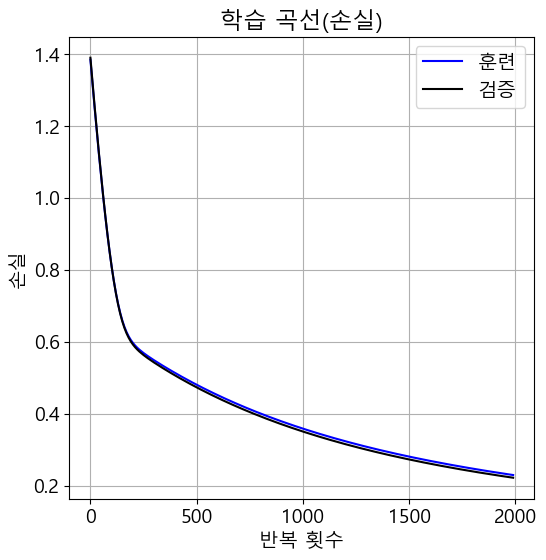

In [33]:
# 학습 곡선 표시(손실)

plt.plot(history[:,0], history[:,1], 'b', label='훈련')
plt.plot(history[:,0], history[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

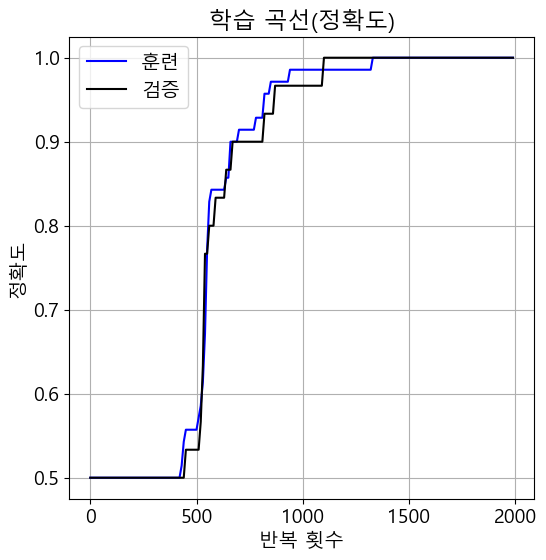

In [34]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], 'b', label='훈련')
plt.plot(history[:,0], history[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

In [35]:
# 파라미터 취득

bias = net.l1.bias.data.numpy()
weight = net.l1.weight.data.numpy()
print(f'BIAS = {bias}, WEIGHT = {weight}')

# 결정 경계를 그리기 위해 x1로부터 x2를 계산
def decision(x):
    return(-(bias + weight[0,0] * x)/ weight[0,1])

# 산포도의 x1의 최솟값과 최댓값
xl = np.array([x_test[:,0].min(), x_test[:,0].max()])
yl = decision(xl)

# 결과 확인
print(f'xl = {xl}  yl = {yl}')

BIAS = [-2.0315], WEIGHT = [[0.4621 1.7226]]
xl = [1.2 5. ]  yl = [ 0.8574 -0.162 ]


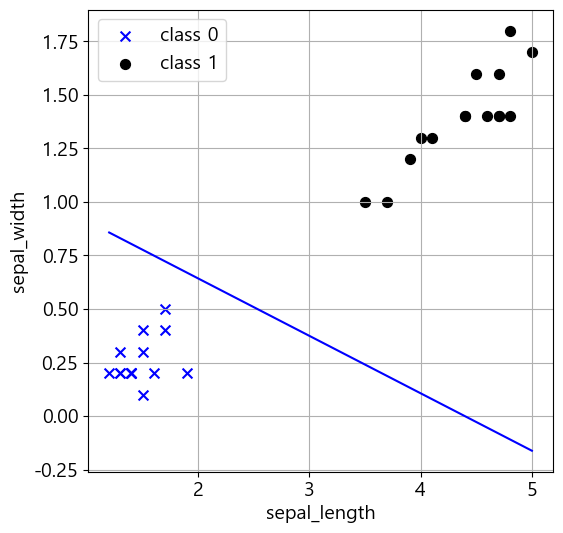

In [36]:
# 산포도 출력
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', 
        c='b', s=50, label='class 0')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', 
        c='k', s=50, label='class 1')

# 결정 경계 직선
plt.plot(xl, yl, c='b')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.show()